# Exploratory Data Analysis for Hydrologic Parameter Modeling

This notebook conducts a comprehensive Exploratory Data Analysis (EDA) on the final, cleaned dataset of ModClark parameters ($T_c$ and $R$) and associated watershed geomorphological characteristics. This process is a foundational step in our modeling pipeline, designed to thoroughly investigate the data's structure, uncover underlying relationships, and identify potential issues before committing to a final model.

The insights gained from this EDA will directly inform critical decisions, including feature selection, preprocessing strategies like scaling and transformations, and the ultimate choice and configuration of our machine learning models. A key objective is to empirically compare our two candidate datasets—the hybrid, time-aware `df_master` and the fully aggregated `df_master_watershed_only`—to validate our data preparation strategy. By systematically exploring the data first, we can build more robust, accurate, and interpretable models.

## Analysis Workflow

The analysis will proceed through the following stages:

* 1. **Dataset Overview and Target Analysis:** The initial step involves a high-level examination of the datasets. We will compute summary statistics and verify data integrity by checking for any remaining missing values. A central focus will be on analyzing the distributions of our target variables, $T_c$ and $R$. By creating overlaid histograms of the targets from both the hybrid and watershed-only dataframes, we can visually quantify the variance captured by the more detailed dataset, providing strong justification for its use in modeling.

* 2. **Univariate Feature Analysis:** We will investigate each geomorphological feature individually to understand its intrinsic properties. By generating histograms and box plots, we can assess each feature's central tendency, spread, modality, and skewness, while also identifying potential outliers. This understanding is crucial for selecting appropriate preprocessing methods, such as log transformations for skewed data or specific scaling techniques required by certain models like SVM.

* 3. **Bivariate Analysis (Feature-Target Relationships):** This step focuses on the core relationships we aim to model. We will generate scatter plots for each geomorphological feature against both $T_c$ and $R$. These plots are essential for visually identifying the form of the relationship—whether it is linear, non-linear (e.g., exponential, logarithmic), or non-existent. This visual assessment will directly guide the feature engineering process, especially for creating transformed features to meet the linearity assumptions of our OLS and Elastic Net regression models.

* 4. **Multivariate Analysis (Inter-Feature Relationships):** To understand the interplay between our predictor variables, we will compute a Pearson correlation matrix. This matrix will be visualized as a **heatmap** for quick and intuitive identification of highly correlated features. Diagnosing this **multicollinearity** is critical, as it can affect the stability and interpretability of coefficient estimates in linear models. This analysis provides valuable context for understanding feature interactions, even for models like Random Forests that are robust to multicollinearity.

* 5. **Preliminary Feature Importance Assessment:** As a final EDA step, we will use a model-based approach to get a holistic view of predictor influence. By training a preliminary **Random Forest** model—a powerful ensemble method that is robust to many data complexities—we can generate a feature importance ranking. This provides an early, data-driven indication of the most influential geomorphological characteristics, helping to confirm that our model is learning hydrologically sensible relationships and allowing us to focus our attention during the final modeling stages.

In [ ]:
# Set root folder for the project
from pathlib import Path

# Custom Modules
PROJECT_ROOT = Path.cwd().parent.parent

In [5]:
# Load dataframes
import pandas as pd
df_master_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/df_master.csv"
df_master_watershed_only_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/df_master_watershed_only.csv"

df_master = pd.read_csv(df_master_path, dtype={'ws_id':str})
df_master_watershed_only = pd.read_csv(df_master_watershed_only_path, dtype={'ws_id':str})

### 1. Dataset Overview and Target Analysis

--- Dataset: df_master (Hybrid Aggregation) ---
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ws_id                      338 non-null    object 
 1   year                       338 non-null    int64  
 2   tc                         338 non-null    float64
 3   r                          338 non-null    float64
 4   pct_developed              292 non-null    float64
 5   pct_forest                 292 non-null    float64
 6   pct_agriculture            292 non-null    float64
 7   pct_grass_scrub            292 non-null    float64
 8   pct_wetlands               292 non-null    float64
 9   pct_water                  292 non-null    float64
 10  pct_barren                 292 non-null    float64
 11  basin_area                 338 non-null    float64
 12  drainage_density           338 non-null    float64
 

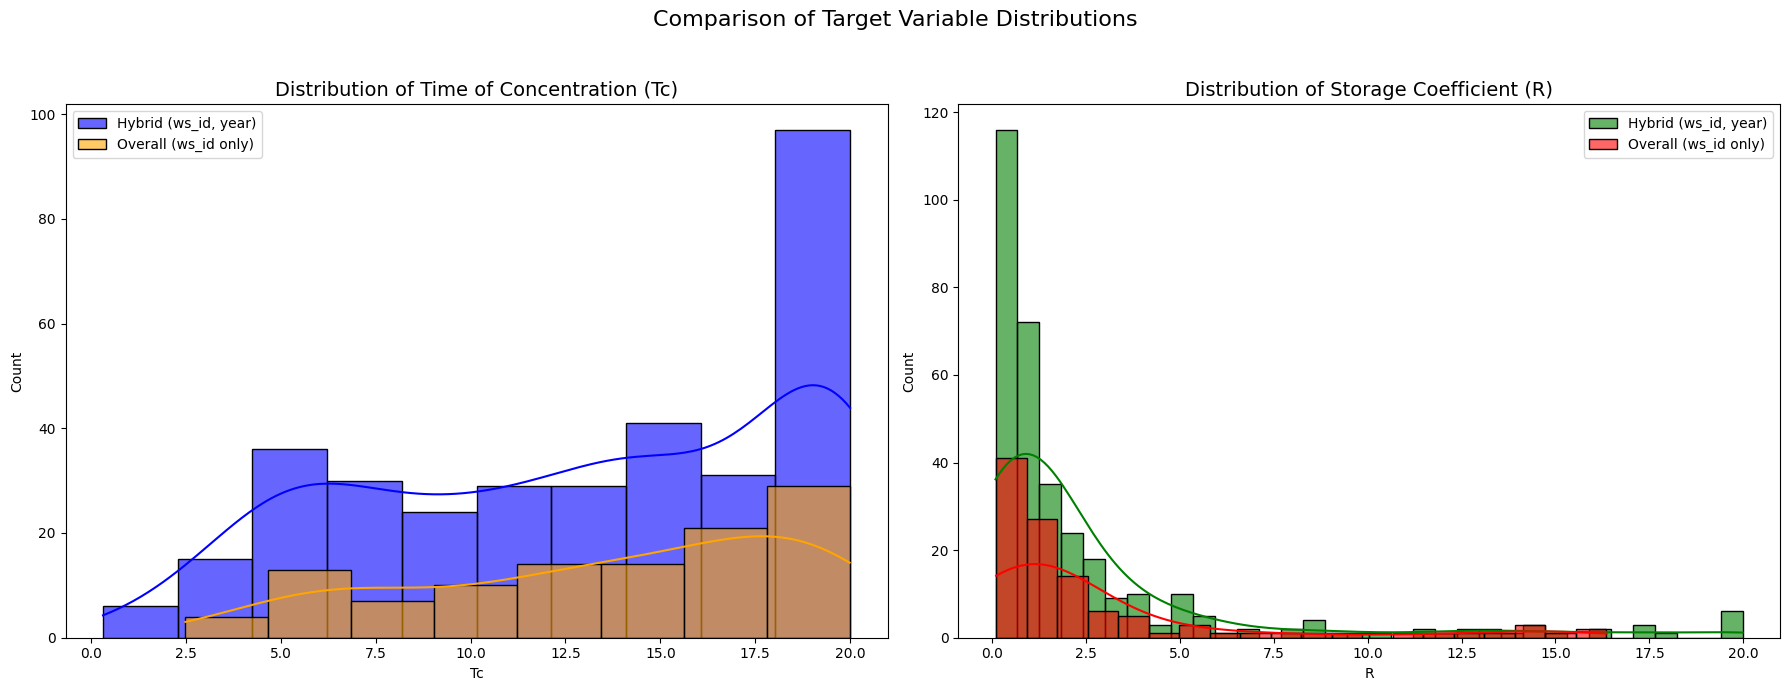

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example placeholder data to make the script runnable
np.random.seed(42)

#-------------------------------------------------------------------------------
## 1.1 Dataset Overview and Integrity Check
#-------------------------------------------------------------------------------

print("--- Dataset: df_master (Hybrid Aggregation) ---")
print("Info:")
df_master.info()
print("\nMissing Values:")
print(df_master.isnull().sum())
print("\nSummary Statistics:")
print(df_master[['tc', 'r']].describe())
print("\n" + "="*50 + "\n")


print("--- Dataset: df_master_watershed_only (Overall Aggregation) ---")
print("Info:")
df_master_watershed_only.info()
print("\nMissing Values:")
print(df_master_watershed_only.isnull().sum())
print("\nSummary Statistics:")
print(df_master_watershed_only[['tc', 'r']].describe())
print("\n" + "="*50 + "\n")


#-------------------------------------------------------------------------------
## 1.2 Target Variable Distribution Analysis (Tc and R)
#-------------------------------------------------------------------------------

print("--- Comparing Target Variable Distributions ---")
# The visualization will show how the distribution of Tc and R changes
# when we average out the yearly variations. A wider distribution for the
# hybrid 'df_master' indicates it captures more variance, which is valuable for modeling.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comparison of Target Variable Distributions', fontsize=16)

# Plot for Tc
sns.histplot(df_master['tc'], ax=axes[0], kde=True, color='blue', alpha=0.6, label='Hybrid (ws_id, year)')
sns.histplot(df_master_watershed_only['tc'], ax=axes[0], kde=True, color='orange', alpha=0.6, label='Overall (ws_id only)')
axes[0].set_title('Distribution of Time of Concentration (Tc)', fontsize=14)
axes[0].set_xlabel('Tc')
axes[0].legend()

# Plot for R
sns.histplot(df_master['r'], ax=axes[1], kde=True, color='green', alpha=0.6, label='Hybrid (ws_id, year)')
sns.histplot(df_master_watershed_only['r'], ax=axes[1], kde=True, color='red', alpha=0.6, label='Overall (ws_id only)')
axes[1].set_title('Distribution of Storage Coefficient (R)', fontsize=14)
axes[1].set_xlabel('R')
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Analysis**

The variation (as measured by the standard deviation in relation to the mean) is greater for $T_c$ and $R$, for the complete dataset. It initially suggests, that the complete dataset better explains the variation in the target variables.

### 2. Univariate Feature Analysis

--- Numerical Summary for Geomorphological Features ---


,Count,Mean,Std Dev,Min,25%,Median,75%,Max,IQR,Skewness,Kurtosis
Feature,,,,,,,,,,,
basin_area,338,3.781277e+07,4.189897e+07,876108.223,8328540.082,2.175679e+07,5.297832e+07,1.938011e+08,4.464978e+07,1.506,1.239
drainage_density,338,2.000000e-03,1.000000e-03,0.001,0.001,2.000000e-03,3.000000e-03,5.000000e-03,2.000000e-03,0.706,-0.392
stream_length,338,1.300896e+04,8.808765e+03,1890.511,6366.658,1.024148e+04,1.695861e+04,4.467503e+04,1.059195e+04,1.039,0.768
basin_length,338,1.363730e+04,9.112224e+03,2081.869,6697.492,1.066592e+04,1.777018e+04,4.603185e+04,1.107269e+04,1.014,0.674
centroidal_flowpath,338,6.056192e+03,4.768531e+03,228.109,2442.494,4.560530e+03,7.963693e+03,2.394367e+04,5.521199e+03,1.311,1.332
main_channel_slope,338,6.000000e-03,1.100000e-02,0.000,0.002,3.000000e-03,6.000000e-03,8.400000e-02,4.000000e-03,4.701,26.644
flowpath_1085_slope,338,5.000000e-03,8.000000e-03,0.000,0.001,2.000000e-03,5.000000e-03,5.000000e-02,4.000000e-03,3.328,12.284
basin_slope,338,9.800000e-02,9.200000e-02,0.008,0.032,6.600000e-02,1.250000e-01,4.450000e-01,9.300000e-02,1.713,2.737
basin_relief,338,9.213600e+01,7.403800e+01,8.172,39.871,6.994100e+01,1.139330e+02,4.584670e+02,7.406100e+01,2.096,6.412




--- Visual Analysis for 16 Geomorphological Features ---


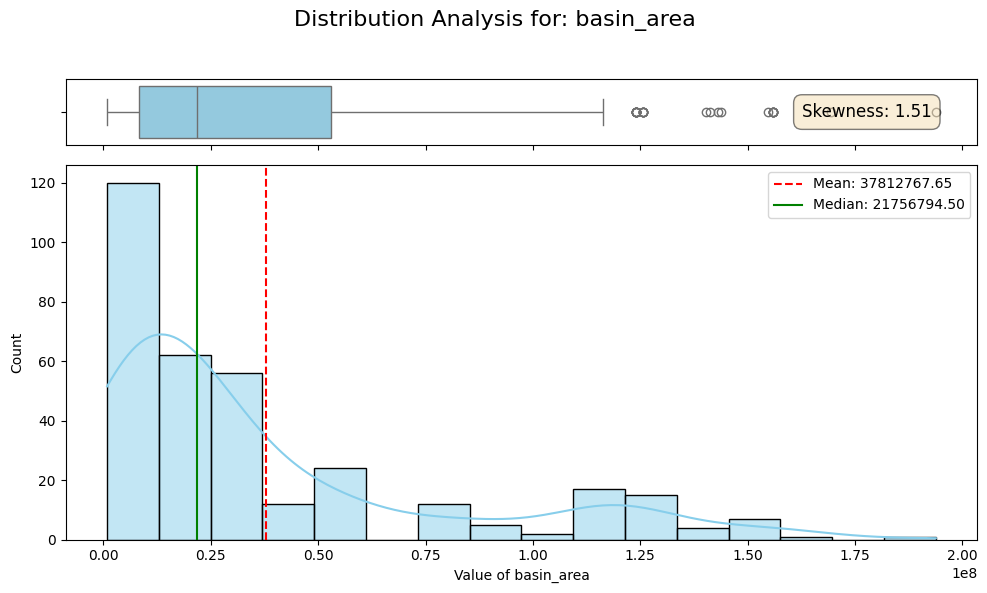

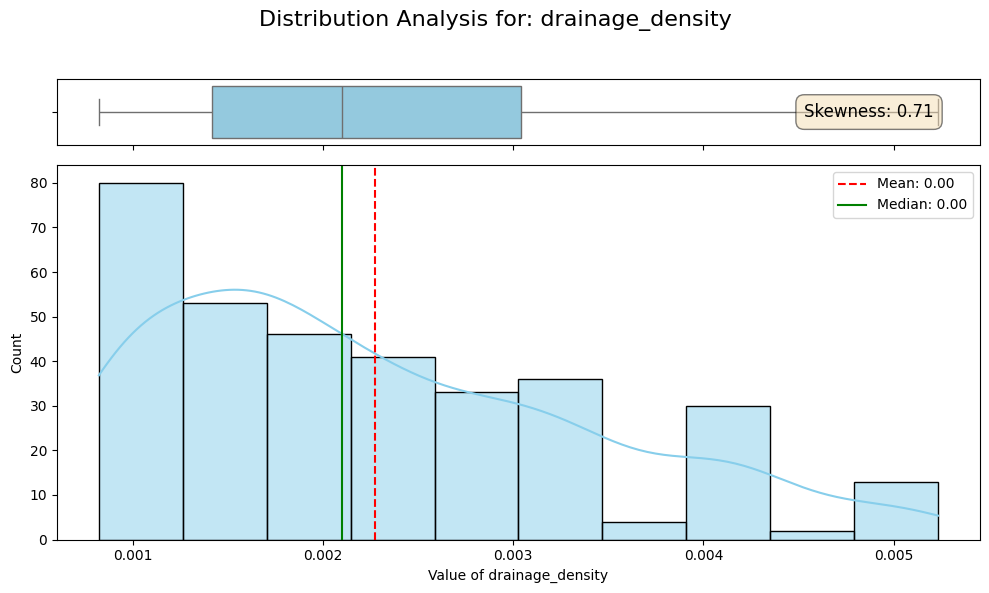

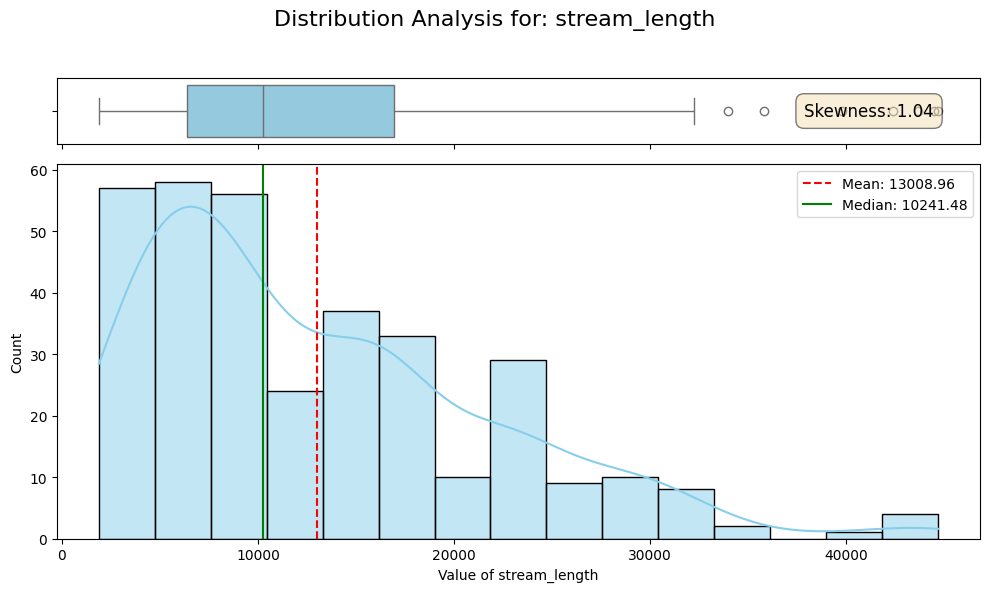

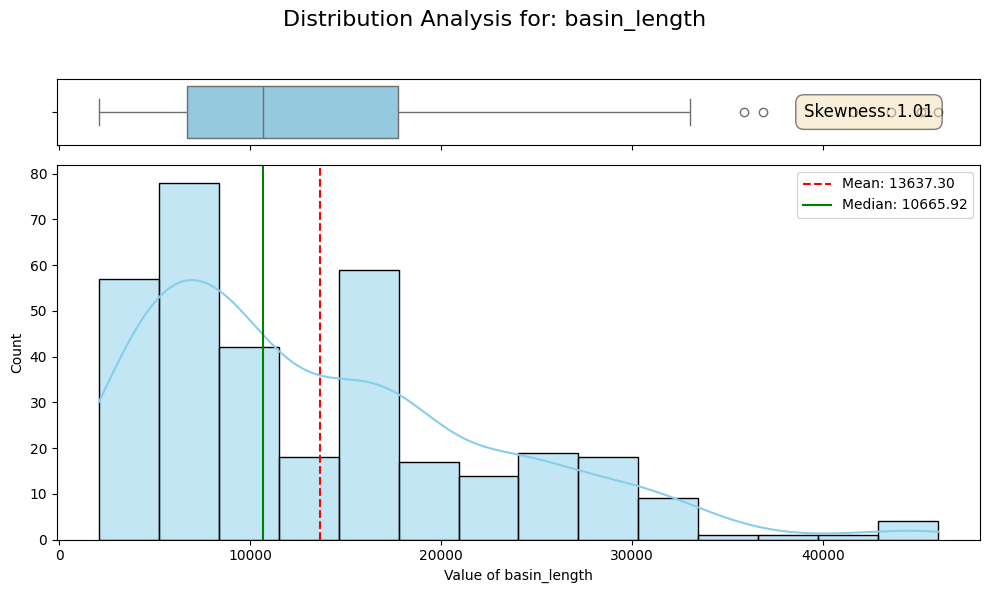

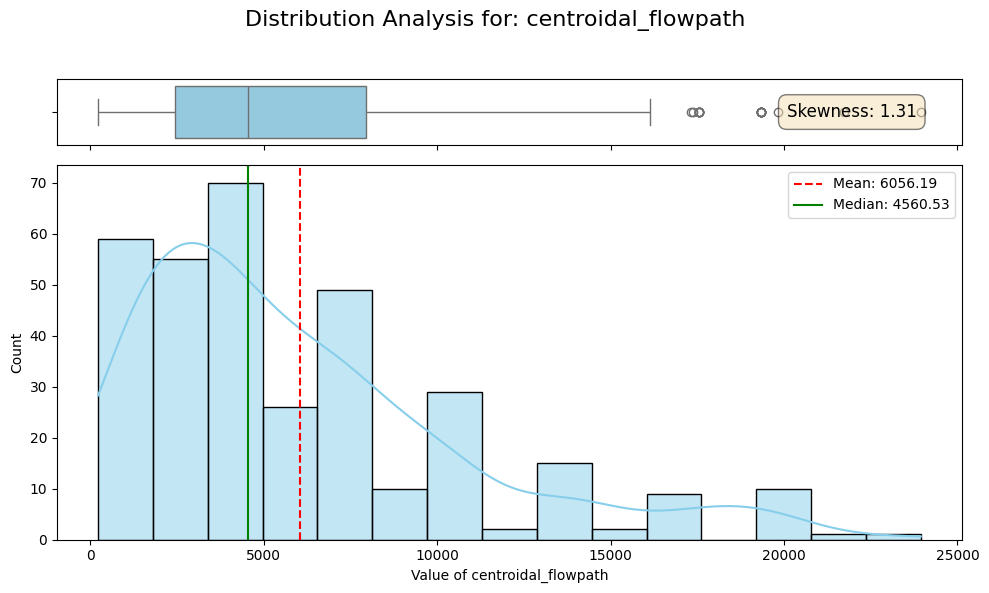

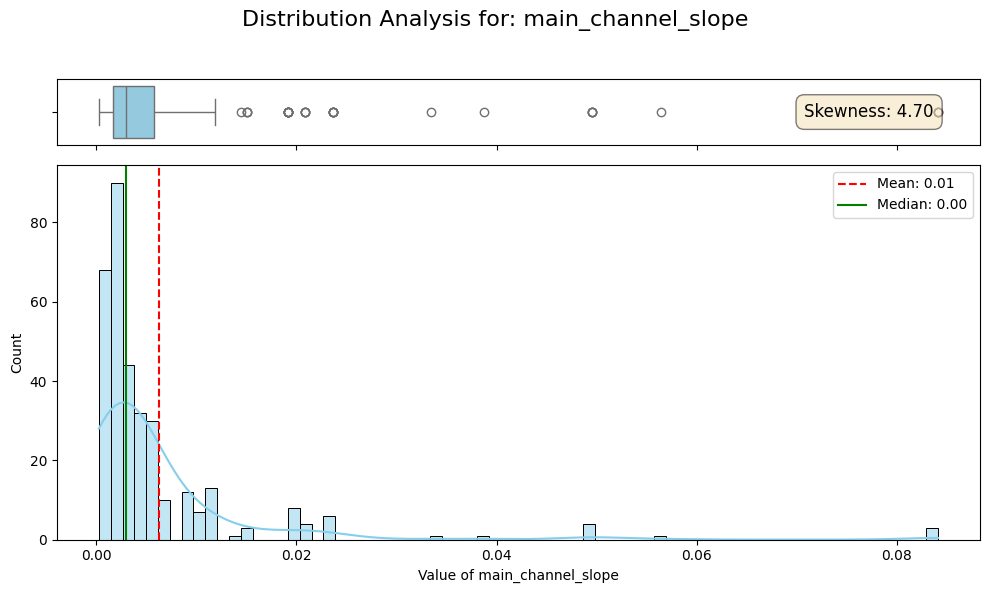

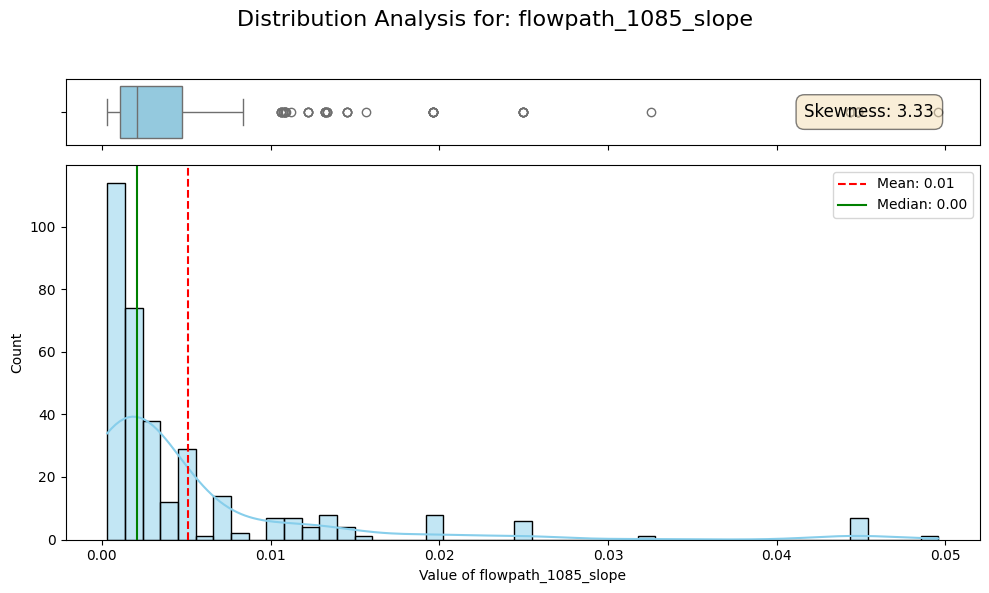

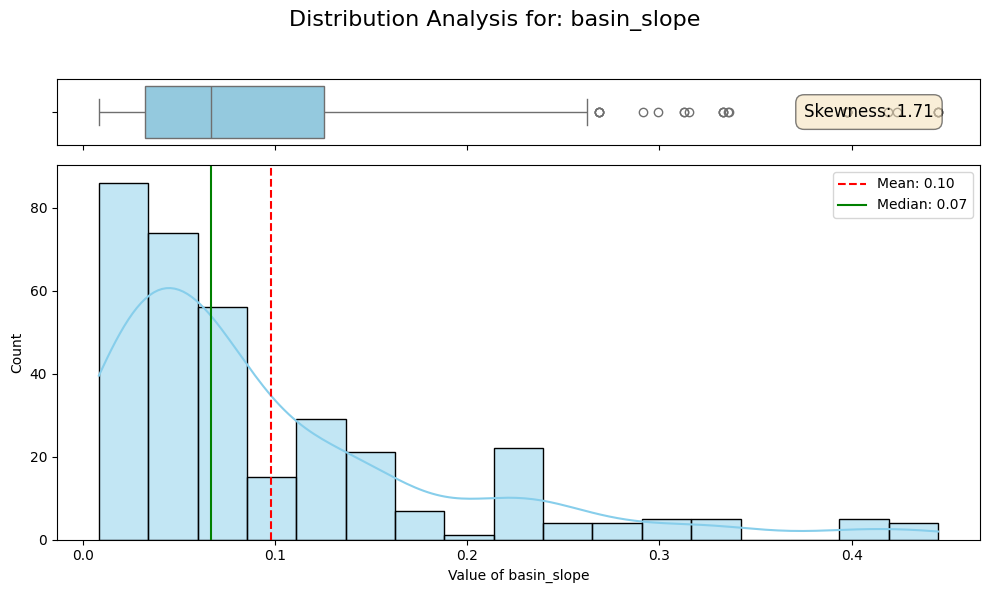

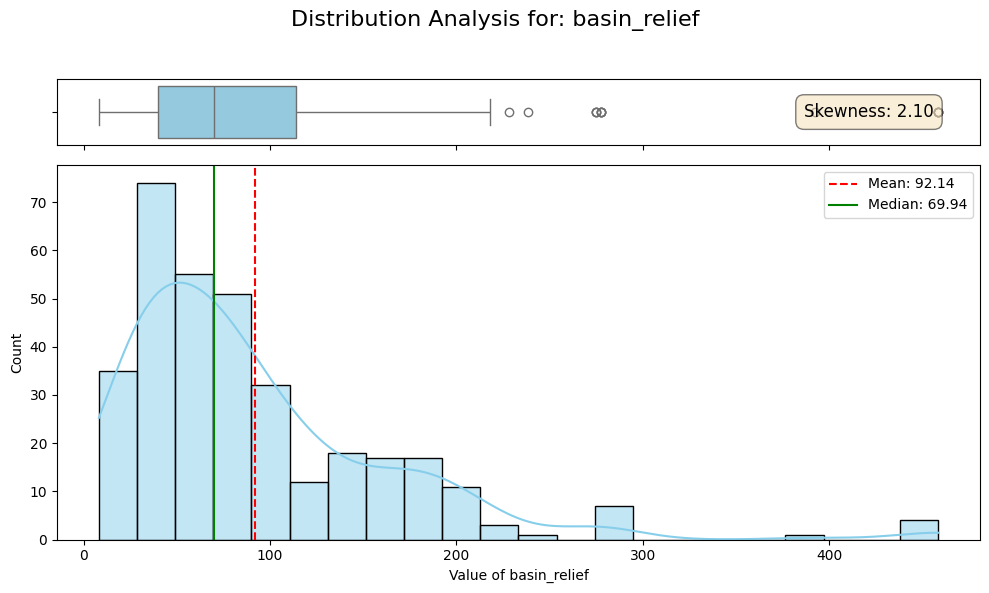

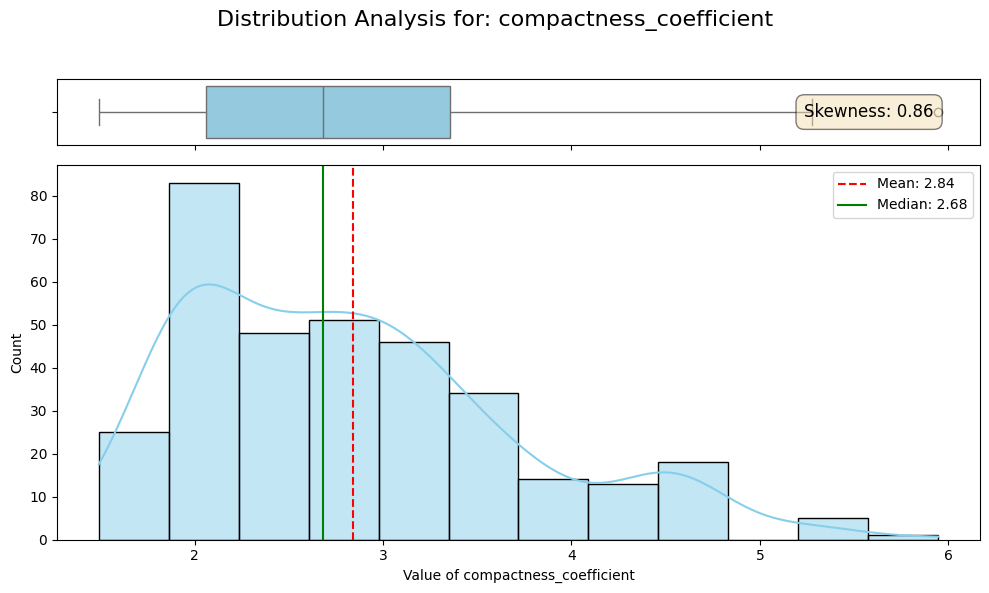

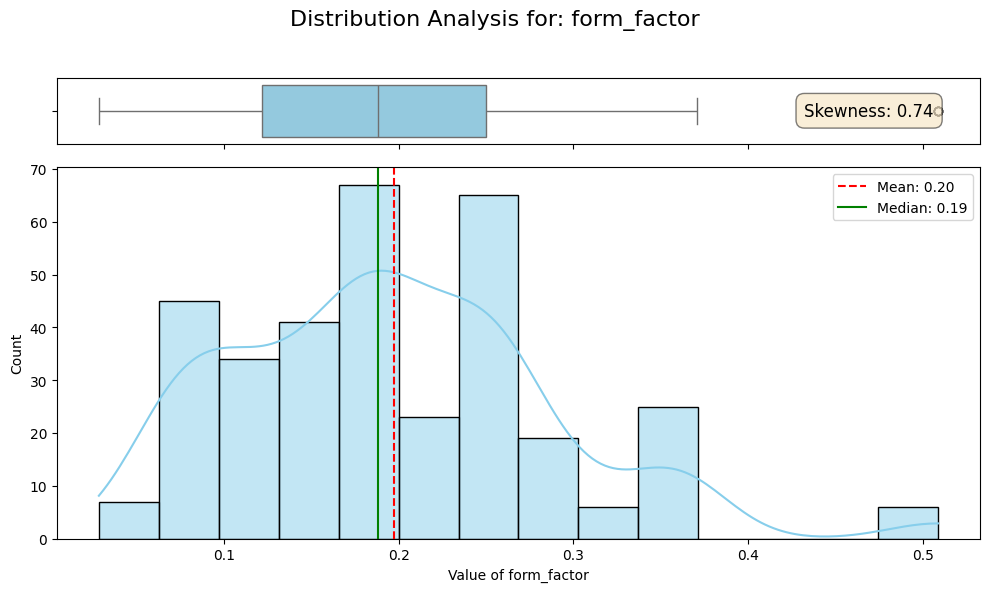

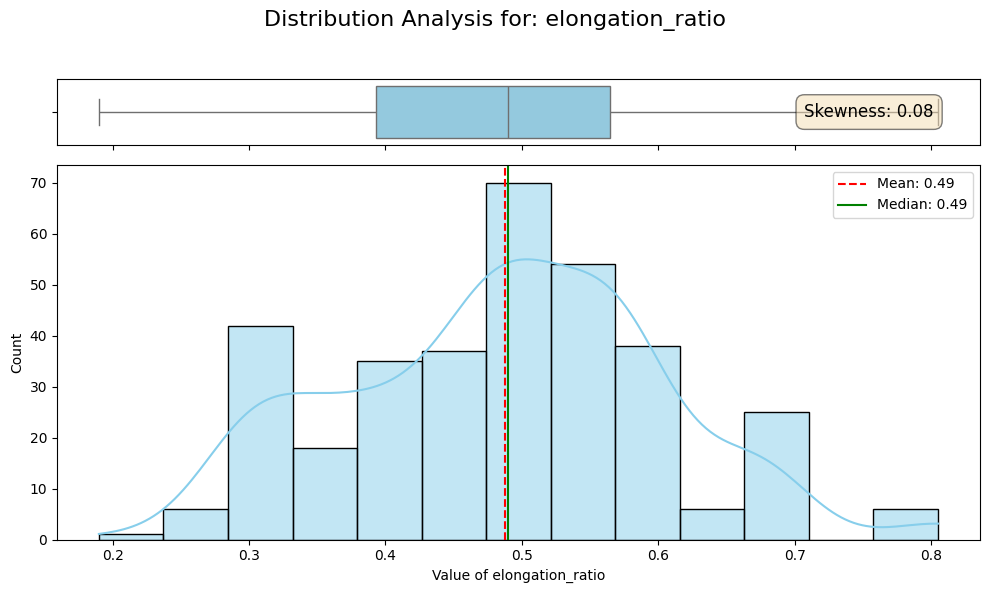

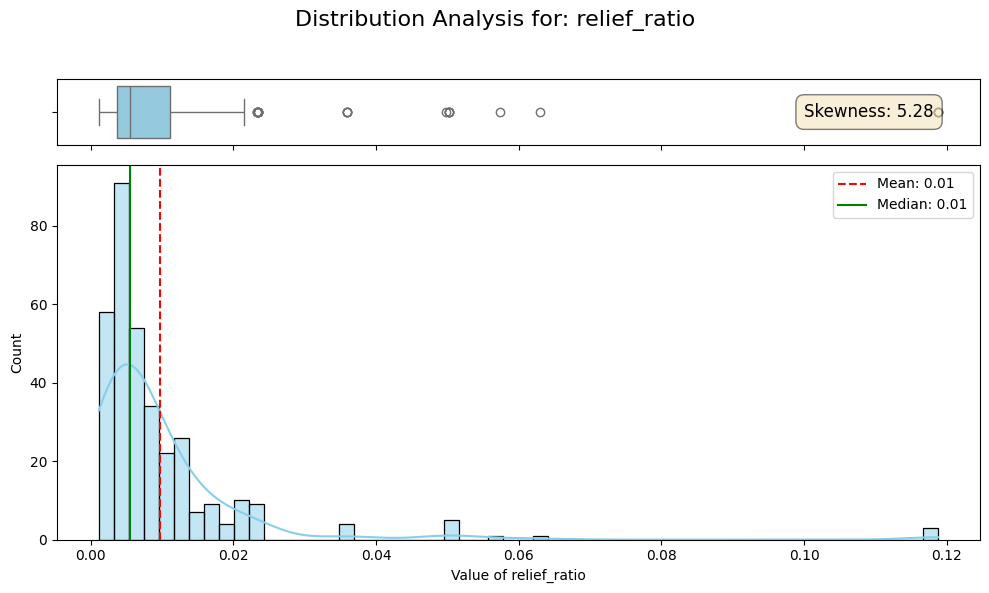

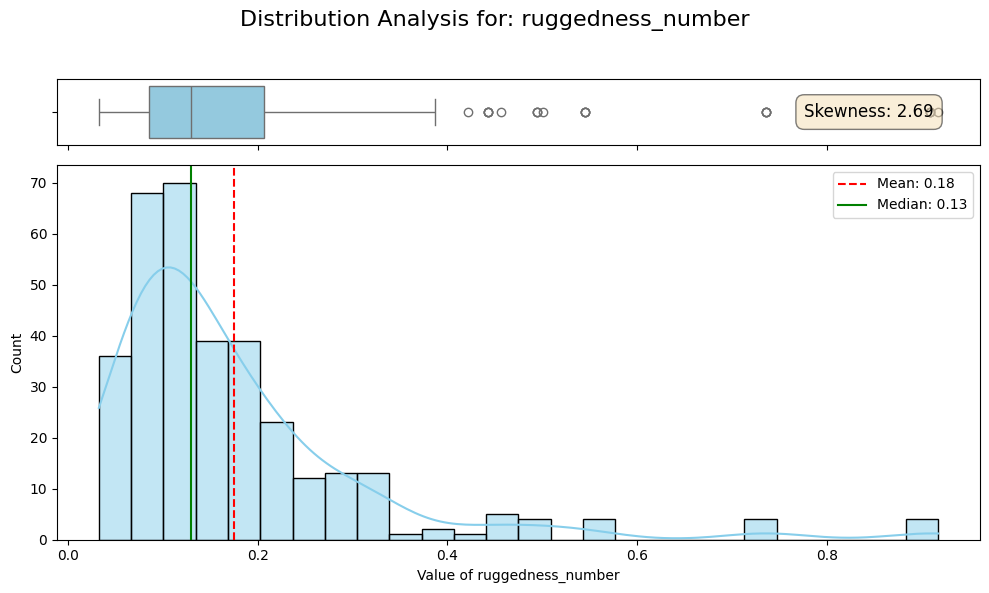

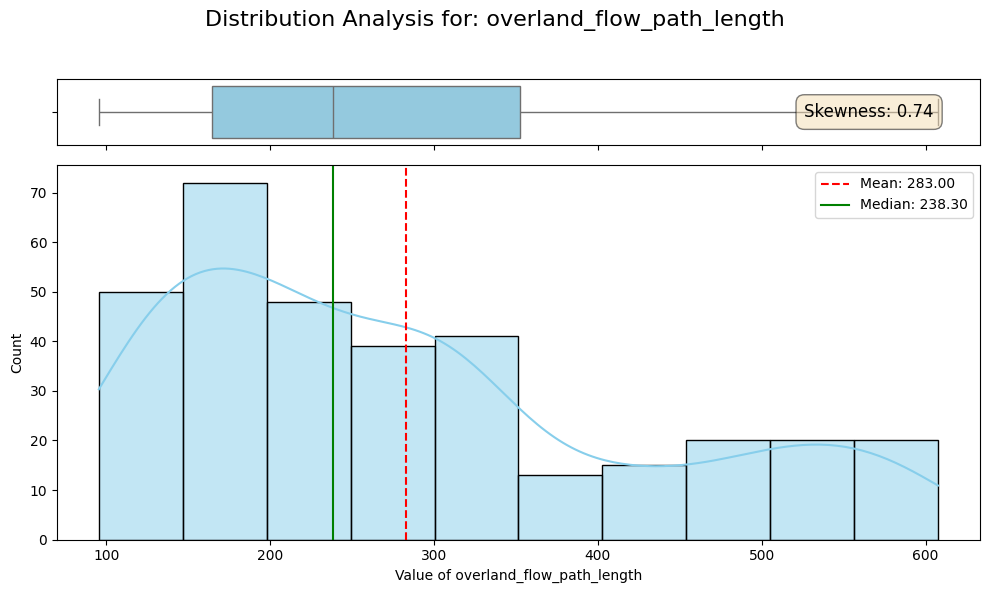

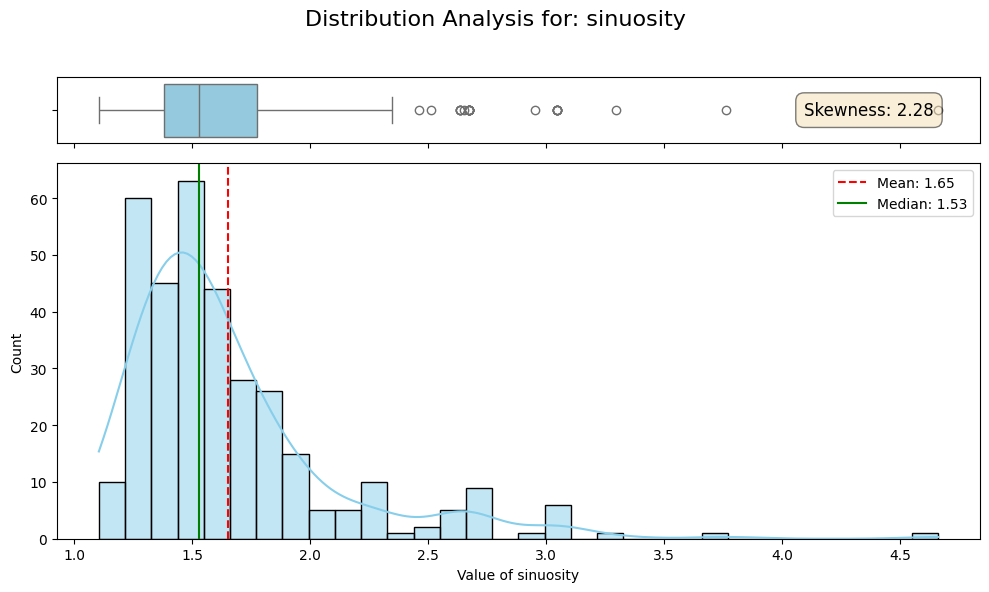

In [8]:
from scipy.stats import skew, kurtosis

#-------------------------------------------------------------------------------
## 2.1 Univariate Feature Analysis
#-------------------------------------------------------------------------------

# Define the list of geomorphological features to analyze
geomorph_features = [
    'basin_area', 'drainage_density', 'stream_length', 'basin_length',
    'centroidal_flowpath', 'main_channel_slope', 'flowpath_1085_slope',
    'basin_slope', 'basin_relief', 'compactness_coefficient', 'form_factor',
    'elongation_ratio', 'relief_ratio', 'ruggedness_number',
    'overland_flow_path_length', 'sinuosity'
]

# Filter the list to only include columns that actually exist in the dataframe
geomorph_features_present = [f for f in geomorph_features if f in df_master.columns]

# --- New Code: Generate Numerical Summary Table ---
print("--- Numerical Summary for Geomorphological Features ---")
stats_list = []
for feature in geomorph_features_present:
    # Use .describe() to get most stats
    desc = df_master[feature].describe()
    
    # Calculate additional stats
    stats_dict = {
        'Feature': feature,
        'Count': int(desc['count']),
        'Mean': desc['mean'],
        'Std Dev': desc['std'],
        'Min': desc['min'],
        '25%': desc['25%'],
        'Median': desc['50%'],
        '75%': desc['75%'],
        'Max': desc['max'],
        'IQR': desc['75%'] - desc['25%'],
        'Skewness': skew(df_master[feature].dropna()),
        'Kurtosis': kurtosis(df_master[feature].dropna())
    }
    stats_list.append(stats_dict)

# Create and display the summary DataFrame
df_summary_stats = pd.DataFrame(stats_list).set_index('Feature')
display(df_summary_stats.round(3)) # display() is better for notebooks
print("\n" + "="*80 + "\n")

print(f"--- Visual Analysis for {len(geomorph_features_present)} Geomorphological Features ---")
# Loop through each feature and create a combined plot
for feature in geomorph_features_present:
    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={'height_ratios': (0.15, 0.85)}
    )
    fig.suptitle(f'Distribution Analysis for: {feature}', fontsize=16)

    # --- Box Plot (top) ---
    sns.boxplot(x=df_master[feature], ax=axes[0], color='skyblue')
    axes[0].set(xlabel='')

    # --- Histogram (bottom) ---
    sns.histplot(x=df_master[feature], ax=axes[1], kde=True, color='skyblue')
    axes[1].set_xlabel(f'Value of {feature}')

    # --- Add Mean, Median, and Skewness ---
    mean_val = df_master[feature].mean()
    median_val = df_master[feature].median()
    skew_val = skew(df_master[feature].dropna())

    axes[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[1].legend()

    axes[0].text(0.95, 0.5, f'Skewness: {skew_val:.2f}',
                 transform=axes[0].transAxes,
                 ha='right', va='center', fontsize=12,
                 bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

**Key Insights from Univariate Feature Analysis**

The summary statistics table reveals several critical characteristics of the geomorphological features that will directly inform our data preprocessing strategy.

* **Wide Variation in Feature Scales:** There is a vast difference in the magnitude and range of the features. For instance, `basin_area` is on the order of millions, while slope and density metrics are very small decimals. This confirms that **feature scaling (e.g., Z-score standardization) is essential** for distance-based and regularized models like SVM and Elastic Net to prevent features with larger scales from dominating the model fitting process, as described in methodology.

* **Prevalence of Right-Skewed Distributions:** A majority of the features are not normally distributed and exhibit significant positive (right) skew. This is evident in features where the **`Mean` is substantially larger than the `Median`** and the **`Skewness` is greater than 1**. The most prominent examples include:
    * `relief_ratio` (Skewness: 5.28)
    * `main_channel_slope` (Skewness: 4.70)
    * `ruggedness_number` (Skewness: 2.69)
    * `sinuosity` (Skewness: 2.28)
    * `basin_relief` (Skewness: 2.10)

    This strong skewness provides a clear justification for applying **logarithmic or Box-Cox transformations**. These transformations are necessary to help linearize the relationships with the target variables ($T_c$ and $R$), a key assumption for the OLS model.

* **Indication of Extreme Outliers:** The **high `Kurtosis` values** (much greater than 3) for several features, especially `relief_ratio` (35.5), `main_channel_slope` (26.6), and `flowpath_1085_slope` (12.3), indicate that their distributions have "heavy tails", as seen in the visualization. This confirms the presence of extreme outliers—watersheds with exceptionally high values for these metrics. These outliers are responsible for pulling the mean away from the median and are the primary cause of the high skewness. The planned transformations will also help in mitigating the outsized influence of these data points.

* **Contrasting Distributions for Shape vs. Size/Relief:** Features related to basin shape, such as `elongation_ratio` and `compactness_coefficient`, are comparatively symmetrical (skewness near 0) - see visualization above. In contrast, features describing size (`basin_area`, `stream_length`) and relief/slope (`basin_relief`, `main_channel_slope`) are the ones that are highly skewed. This suggests that a one-size-fits-all preprocessing approach may not be optimal; different transformations might be suitable for different types of features.

In summary, the numerical analysis strongly supports the planned feature preprocessing pipeline. The significant variation in scale, prevalent skewness, and presence of outliers necessitate the use of scaling and transformations to prepare the data for the selected machine learning models.